In [1]:
import pandas as pd, numpy as np
from pathlib import Path

In [5]:
MERGED = '/Users/aniruddh/capstone_fall25/ai-mill-tool/models/AL_LaneOne_Merged_inner.csv'
df = pd.read_csv(MERGED, low_memory=False)



In [7]:
for c in ["CallReadyDate","PickUpDate","DeliveredDate","Ship Date","Mill Ready Dt","Delivered Date","Created Date"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

In [9]:
num_cols_try = [
    "SalePrice","TotalCost","LumberCost","ActFreightCost","CarrierCost","EstFreight",
    "ReceivingFee","ContributionFee","BF","ConvBF","DATRate","FreightFactor",
    "LOT Revenue","LOT Carrier Expense","LOT Gross Profit","Miles/Class"
]
for c in num_cols_try:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

In [11]:
#keeping only trainable lines : 



work = df.copy()

if "poType" in work.columns:
    work = work[work["poType"].astype(str).str.contains("Direct", case=False, na=False)]



#ensuring sale_price is present and positive 

work = work[work["SalePrice"].notna() & (work["SalePrice"] > 0)]




#MBF with fallback to ConvBF


def compute_mbf(row):
    if pd.notna(row.get("BF", np.nan)) and row["BF"] > 0:
        return row["BF"] / 1000.0
    if pd.notna(row.get("ConvBF", np.nan)) and row["ConvBF"] > 0:
        return row["ConvBF"] / 1000.0
    return np.nan


In [13]:
work["MBF"] = work.apply(compute_mbf, axis=1)
work = work[work["MBF"].notna() & (work["MBF"] > 0)]

In [22]:
 #Prefer provided TotalCost; if missing/NaN, rebuild conservatively from available components
has_total = "TotalCost" in work.columns
if (not has_total) or work["TotalCost"].isna().any():
    parts = []
    for c in ["LumberCost","ActFreightCost","CarrierCost","EstFreight","ReceivingFee","ContributionFee"]:
        if c in work.columns:
            parts.append(work[c].fillna(0.0))
    if parts:
        work["_RebuiltCost"] = np.vstack(parts).sum(axis=0)
        if has_total:
            work["TotalCost_clean"] = work["TotalCost"].fillna(work["_RebuiltCost"])
        else:
            work["TotalCost_clean"] = work["_RebuiltCost"]
    else:
        # worst-case fallback
        base = work["LumberCost"].fillna(0.0) if "LumberCost" in work.columns else 0.0
        work["TotalCost_clean"] = base
else:
    work["TotalCost_clean"] = work["TotalCost"]

In [24]:
work["GP_per_MBF"] = (work["SalePrice"] - work["TotalCost_clean"]) / work["MBF"]

In [26]:
q1, q99 = work["GP_per_MBF"].quantile([0.01, 0.99])
work = work[(work["GP_per_MBF"] >= q1) & (work["GP_per_MBF"] <= q99)]
work = work.replace([np.inf, -np.inf], np.nan).dropna(subset=["GP_per_MBF"])

In [28]:
#pre decision features 



cat_cols = [c for c in [
    "Mill","VendorCID","CustomerName","BuyerName","Salesman",
    "Grade","Species","PurchaseUOM","SaleUOM","ShipVia",
    "OriginST","DestST","Pickup State","Consignee State",
    "poType","ContractPurchase","Type of Shipment"
] if c in work.columns]

num_cols = [c for c in [
    "BF","ConvBF","FreightFactor","EstFreight","DATRate"
] if c in work.columns]

date_col = "CallReadyDate" if "CallReadyDate" in work.columns else ("PickUpDate" if "PickUpDate" in work.columns else None)
if date_col:
    work["Year"]  = work[date_col].dt.year
    work["Month"] = work[date_col].dt.month
    work["Dow"]   = work[date_col].dt.dayofweek
    num_cols += ["Year","Month","Dow"]

leak = {"DeliveredDate","Ship Date","Delivered Date","Mill Ready Dt","ActFreightCost","CarrierCost",
        "LOT Revenue","LOT Carrier Expense","LOT Gross Profit","LOT Profit %"}
use_cols = [c for c in (cat_cols + num_cols) if c not in leak]
model_df = work[use_cols + ["GP_per_MBF", "MBF", date_col]].dropna(subset=["GP_per_MBF"])


In [32]:
import pandas as pd
import numpy as np

# 0) Make sure we actually have a usable date column
if date_col is None or model_df[date_col].isna().all():
    raise ValueError("No usable pre-decision date column found for time split.")

# 1) Keep only rows with a valid date, sort chronologically
chron = model_df.dropna(subset=[date_col]).sort_values(date_col).reset_index(drop=True)

# 2) Pick cut points by time quantiles (60/80), not by counts, to keep order
q_train = 0.60
q_val   = 0.80

t1 = chron[date_col].quantile(q_train)  # train_end
t2 = chron[date_col].quantile(q_val)    # val_end

# 3) Build splits (strictly chronological, left-closed/right-open for val)
train = chron[chron[date_col] <= t1].copy()
val   = chron[(chron[date_col] > t1) & (chron[date_col] <= t2)].copy()
test  = chron[chron[date_col] > t2].copy()

# 4) Diagnostics: sizes and date ranges
def rng(df):
    if df.empty: 
        return ("∅","∅")
    return (df[date_col].min().date(), df[date_col].max().date())

print("Rows  :", len(train), len(val), len(test))
print("Ranges:",
      f"train {rng(train)} |",
      f"val {rng(val)} |",
      f"test {rng(test)}")

# 5) Guardrail: if train is still too small (e.g., < 10% of data), relax to 70/15/15
total = len(chron)
if len(train) < 0.10 * total:
    t1 = chron[date_col].quantile(0.70)
    t2 = chron[date_col].quantile(0.85)
    train = chron[chron[date_col] <= t1].copy()
    val   = chron[(chron[date_col] > t1) & (chron[date_col] <= t2)].copy()
    test  = chron[chron[date_col] > t2].copy()
    print("\nAdjusted to 70/15/15 because train was too small.")
    print("Rows  :", len(train), len(val), len(test))
    print("Ranges:",
          f"train {rng(train)} |",
          f"val {rng(val)} |",
          f"test {rng(test)}")

Rows  : 4570 1509 1506
Ranges: train (datetime.date(2024, 12, 3), datetime.date(2025, 5, 14)) | val (datetime.date(2025, 5, 15), datetime.date(2025, 7, 10)) | test (datetime.date(2025, 7, 10), datetime.date(2025, 8, 29))


In [40]:
print(train.shape, test.shape, val.shape)


(4570, 28) (1506, 28) (1509, 28)


In [57]:
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error


In [61]:
target = "GP_per_MBF"
cat_idx = [i for i,c in enumerate(use_cols) if c in cat_cols]



binary_keep_numeric = {"ContractPurchase"}  # add/remove as needed
cat_cols = [c for c in cat_cols if c not in binary_keep_numeric]

# 2) Fill NA then cast to string for all categoricals (train/val/test)
for _df in (train, val, test):
    if cat_cols:
        _df[cat_cols] = _df[cat_cols].fillna("__NA__").astype(str)

# 3) (Optional but recommended) ensure numerics are truly numeric
safe_numeric = set(use_cols) - set(cat_cols)
for _df in (train, val, test):
    for c in safe_numeric:
        # if a column is supposed to be numeric but got object dtype, coerce it
        if _df[c].dtype == "object":
            _df[c] = pd.to_numeric(_df[c], errors="coerce")

# 4) Recompute cat_idx AFTER any changes to cat_cols/use_cols
cat_idx = [i for i, c in enumerate(use_cols) if c in cat_cols]





In [63]:
train_pool = Pool(train[use_cols], label=train[target], cat_features=cat_idx)
val_pool   = Pool(val[use_cols],   label=val[target],   cat_features=cat_idx)
test_pool  = Pool(test[use_cols],  label=test[target],  cat_features=cat_idx)

cb = CatBoostRegressor(
    loss_function="MAE",
    depth=8,
    learning_rate=0.06,
    l2_leaf_reg=6.0,
    random_seed=42,
    iterations=4000,
    od_type="Iter",
    od_wait=200,
    verbose=200
)
cb.fit(train_pool, eval_set=val_pool)

val_pred  = cb.predict(val_pool)
test_pred = cb.predict(test_pool)

0:	learn: 82.7877921	test: 105.6080966	best: 105.6080966 (0)	total: 72.7ms	remaining: 4m 50s
200:	learn: 21.3566342	test: 79.1861537	best: 77.7422426 (35)	total: 1.41s	remaining: 26.6s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 77.74224264
bestIteration = 35

Shrink model to first 36 iterations.


In [65]:
print("MAE (Val):", mean_absolute_error(val[target], val_pred))
print("MAE (Test):", mean_absolute_error(test[target], test_pred))

MAE (Val): 77.74224367195396
MAE (Test): 90.29389489664466


In [67]:
imp = cb.get_feature_importance(type="FeatureImportance")
feat_imp = pd.DataFrame({"feature": use_cols, "importance": imp}).sort_values("importance", ascending=False)
feat_imp.head(20)

,feature,importance
17,BF,24.768169
5,Grade,20.525406
3,BuyerName,12.150364
8,SaleUOM,10.260930
23,Month,8.760519
18,ConvBF,4.451582
7,PurchaseUOM,3.649592
10,OriginST,2.077375
13,Consignee State,2.055672
2,CustomerName,2.025839


In [79]:
TARGET = target


cb_v2 = CatBoostRegressor(
    loss_function="MAE",
    depth=8,
    learning_rate=0.03,   # lower LR
    l2_leaf_reg=10.0,     # stronger regularization
    subsample=0.8,        # row sampling
    rsm=0.8,              # feature sampling
    random_seed=42,
    iterations=8000,
    od_type="Iter",
    od_wait=300,
    verbose=200
)


cb_v2.fit(train_pool, eval_set=val_pool)

val_pred_v2  = cb_v2.predict(val_pool)
test_pred_v2 = cb_v2.predict(test_pool)

from collections import OrderedDict
results = OrderedDict([
    # ("Baseline_Global_Val",  mean_absolute_error(val[TARGET],  val_pred_baseline_global)),
    # ("Baseline_Global_Test", mean_absolute_error(test[TARGET], test_pred_baseline_global)),
    # ("Baseline_Lane_Val",    mean_absolute_error(val[TARGET],  val_pred_baseline_lane)),
    # ("Baseline_Lane_Test",   mean_absolute_error(test[TARGET], test_pred_baseline_lane)),
    ("CatBoost_v1_Val",      mean_absolute_error(val[target],  val_pred)),     # from your earlier run
    ("CatBoost_v1_Test",     mean_absolute_error(test[target], test_pred)),
    ("CatBoost_v2_Val",      mean_absolute_error(val[TARGET],  val_pred_v2)),
    ("CatBoost_v2_Test",     mean_absolute_error(test[TARGET], test_pred_v2)),
])

pd.DataFrame.from_dict(results, orient="index", columns=["MAE_$per_MBF"])


0:	learn: 84.2427862	test: 106.7117253	best: 106.7117253 (0)	total: 16.7ms	remaining: 2m 13s
200:	learn: 28.3481050	test: 78.7970481	best: 77.7921637 (72)	total: 1.32s	remaining: 51.3s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 77.79216368
bestIteration = 72

Shrink model to first 73 iterations.


,MAE_$per_MBF
CatBoost_v1_Val,77.742244
CatBoost_v1_Test,90.293895
CatBoost_v2_Val,77.792165
CatBoost_v2_Test,90.458641


In [83]:
eval_df = pd.DataFrame({
    "actual_per_mbf": test[target].values,
    "pred_per_mbf":   test_pred
})
eval_df["resid_per_mbf"] = eval_df["actual_per_mbf"] - eval_df["pred_per_mbf"]

# Bring MBF and useful business context if present
keep_ctx = [c for c in ["MBF","Mill","CustomerName","OriginST","DestST","Type of Shipment",date_col,
                        "poRecordID","ItemID","AljexProNum","Pro #"] if c in test.columns]
for c in keep_ctx:
    eval_df[c] = test[c].values

# Dollar views (if MBF available)
if "MBF" in eval_df.columns:
    eval_df["actual_gp_$"] = eval_df["actual_per_mbf"] * eval_df["MBF"]
    eval_df["pred_gp_$"]   = eval_df["pred_per_mbf"]   * eval_df["MBF"]
    eval_df["resid_gp_$"]  = eval_df["actual_gp_$"]    - eval_df["pred_gp_$"]

In [85]:
import pandas as pd
imp = cb.get_feature_importance(type="FeatureImportance")
feat_imp = (pd.DataFrame({"feature": use_cols, "importance": imp})
              .sort_values("importance", ascending=False)
              .head(20))
feat_imp

,feature,importance
17,BF,24.768169
5,Grade,20.525406
3,BuyerName,12.150364
8,SaleUOM,10.260930
23,Month,8.760519
18,ConvBF,4.451582
7,PurchaseUOM,3.649592
10,OriginST,2.077375
13,Consignee State,2.055672
2,CustomerName,2.025839


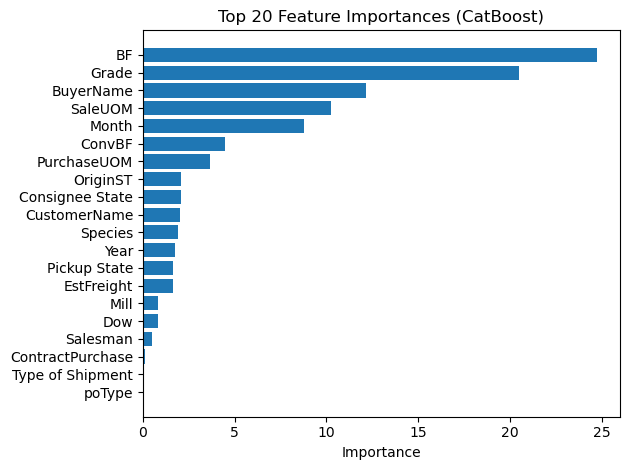

In [87]:
import matplotlib.pyplot as plt

fi = feat_imp.copy()
plt.figure()
plt.barh(range(len(fi)), fi["importance"].values[::-1])
plt.yticks(range(len(fi)), fi["feature"].values[::-1])
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances (CatBoost)")
plt.tight_layout()
plt.show()


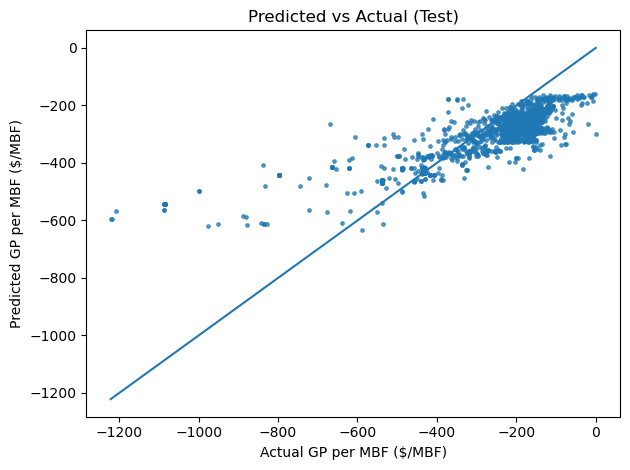

In [89]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(eval_df["actual_per_mbf"], eval_df["pred_per_mbf"], s=6, alpha=0.7)
lo = float(np.nanmin([eval_df["actual_per_mbf"].min(), eval_df["pred_per_mbf"].min()]))
hi = float(np.nanmax([eval_df["actual_per_mbf"].max(), eval_df["pred_per_mbf"].max()]))
plt.plot([lo, hi], [lo, hi])
plt.xlabel("Actual GP per MBF ($/MBF)")
plt.ylabel("Predicted GP per MBF ($/MBF)")
plt.title("Predicted vs Actual (Test)")
plt.tight_layout()
plt.show()

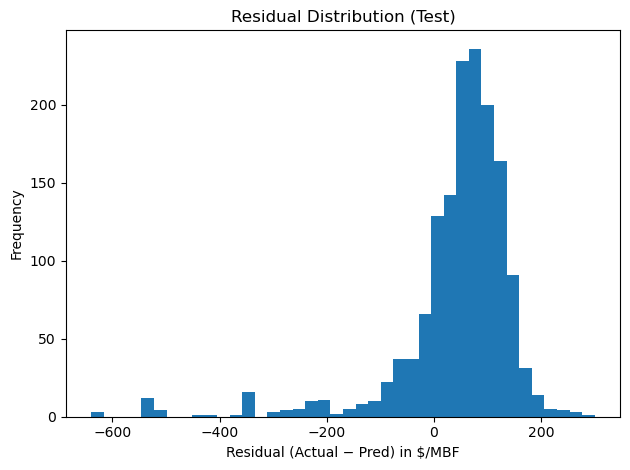

In [91]:
#residual distribution 



import matplotlib.pyplot as plt

plt.figure()
plt.hist(eval_df["resid_per_mbf"].dropna().values, bins=40)
plt.xlabel("Residual (Actual − Pred) in $/MBF")
plt.ylabel("Frequency")
plt.title("Residual Distribution (Test)")
plt.tight_layout()
plt.show()


In [93]:

#biggest dollar misses 

import numpy as np
import pandas as pd

cols = [c for c in ["poRecordID","ItemID","AljexProNum","Pro #","CustomerName","Mill",
                    "OriginST","DestST","Type of Shipment",date_col,
                    "MBF","actual_per_mbf","pred_per_mbf","resid_per_mbf",
                    "actual_gp_$","pred_gp_$","resid_gp_$"] if c in eval_df.columns]

business_view = eval_df.assign(abs_miss=lambda d: d["resid_gp_$"].abs() if "resid_gp_$" in d.columns else np.nan)
business_view = (business_view
                 .sort_values("abs_miss", ascending=False)
                 .reindex(columns=cols + (["abs_miss"] if "abs_miss" in business_view.columns else []))
                 .head(25))
business_view

,CustomerName,Mill,OriginST,DestST,Type of Shipment,CallReadyDate,MBF,actual_per_mbf,pred_per_mbf,resid_per_mbf,actual_gp_$,pred_gp_$,resid_gp_$,abs_miss
980,Connelly & Connelly LLC dba Craters & Freighters,"West Fraser Timber Co, Ltd - 57 (Lanett, AL)",AL,AL,F,2025-08-08 00:00:00,30.464,-140.770221,-353.457550,212.687330,-4288.42400,-10767.730817,6479.306817,6479.306817
637,Mesa Corporation,"West Fraser Timber Co, Ltd - 57 (Lanett, AL)",AL,SC,F,2025-07-31 00:00:00,30.464,-147.482931,-351.223147,203.740216,-4492.92000,-10699.661945,6206.741945,6206.741945
663,The Nelson Company,"West Fraser Timber Co, Ltd - 57 (Lanett, AL)",AL,GA,F,2025-07-31 00:00:00,30.464,-154.684874,-356.660209,201.975335,-4712.32000,-10865.296614,6152.976614,6152.976614
669,The Nelson Company,"West Fraser Timber Co, Ltd - 57 (Lanett, AL)",AL,GA,F,2025-07-31 00:00:00,30.464,-154.684874,-356.660209,201.975335,-4712.32000,-10865.296614,6152.976614,6152.976614
93,"Contractors Supply & Equipment Co, LLC","Georgia-Pacific Corp. (Gurdon, AR)",AR,LA,F,2025-07-15 00:00:00,23.040,-658.958333,-393.372319,-265.586014,-15182.40000,-9063.298234,-6119.101766,6119.101766
1340,Mesa Corporation,"Norbord Industries Inc. (Kinards, SC)",SC,SC,F,2025-08-20 00:00:00,30.464,-149.482920,-346.201517,196.718598,-4553.84766,-10546.683015,5992.835355,5992.835355
1401,"SE Board , Inc","Jordan Lumber & Supply, Inc (Mt. Gilead, NC)",NC,NC,F,2025-08-22 00:00:00,23.040,-87.031250,-335.852766,248.821516,-2005.20000,-7738.047730,5732.847730,5732.847730
1363,"B&C Industries, Inc","Norbord Industries Inc. (Kinards, SC)",SC,KY,F,2025-08-21 00:00:00,30.464,-156.720971,-341.495360,184.774389,-4774.34766,-10403.314653,5628.966993,5628.966993
599,Feralloy Corp DBA FerrouSouth,"Southeastern Timber Products, LLC (Ackerman, MS)",MS,MS,F,2025-07-30 00:00:00,24.405,-79.965786,-308.757064,228.791278,-1951.56500,-7535.216141,5583.651141,5583.651141
253,"Graber Box and Pallet, FLP","Mission Forest Products, LP (Corinth, MS)",MS,IN,F,2025-07-21 00:00:00,23.552,-57.612092,-291.256475,233.644383,-1356.88000,-6859.672507,5502.792507,5502.792507


In [113]:
#helper functions

PLOT_DIR = Path("/Users/aniruddh/capstone_fall25/ai-mill-tool/models/plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)


In [115]:
def _apply_common_ax_format(ax, title, xlabel, ylabel, grid=True, note=None):
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    if grid:
        ax.grid(True, alpha=0.35)
    if note:
        # small note/subtitle at the bottom-right
        ax.text(1.0, -0.18, note, transform=ax.transAxes, ha="right", va="center", fontsize=9)

def _export(fig, filename):
    out = PLOT_DIR / filename
    fig.tight_layout()
    fig.savefig(out, dpi=180, bbox_inches="tight")
    print("Saved:", out)
    plt.show()

def _format_thousands(ax):
    # Add thousands separators to y-axis if values are large
    axis = ax.yaxis
    try:
        from matplotlib.ticker import FuncFormatter
        axis.set_major_formatter(FuncFormatter(lambda x, p: f"{int(x):,}"))
    except Exception:
        pass

In [117]:
def plot_gp_hist(gp_df, filename="gp_hist.png", bins=40):
    """
    gp_df columns expected: pred_gp_per_mbf (required)
    """
    x = gp_df["pred_gp_per_mbf"].dropna().values
    fig, ax = plt.subplots(figsize=(7.5, 5))
    ax.hist(x, bins=bins)
    _apply_common_ax_format(
        ax,
        title="Predicted GP per MBF – Distribution",
        xlabel="Predicted GP per MBF ($/MBF)",
        ylabel="Count",
        note=f"N={len(x)} | p50={np.nanmedian(x):.1f} | p80={np.nanpercentile(x,80):.1f}"
    )
    _export(fig, filename)

def plot_gp_line_dollars(gp_df, filename="gp_line_dollars.png", bins=40):
    """
    gp_df columns expected: pred_gp_$ (required)
    """
    if "pred_gp_$" not in gp_df.columns:
        print("pred_gp_$ not found; skipping.")
        return
    x = gp_df["pred_gp_$"].dropna().values
    fig, ax = plt.subplots(figsize=(7.5, 5))
    ax.hist(x, bins=bins)
    _apply_common_ax_format(
        ax,
        title="Predicted Line GP – Distribution",
        xlabel="Predicted Line GP ($)",
        ylabel="Count",
        note=f"N={len(x)} | p50=${np.nanmedian(x):,.0f} | p80=${np.nanpercentile(x,80):,.0f}"
    )
    _format_thousands(ax)
    _export(fig, filename)

def plot_gp_vs_size(gp_df, policy_floor=60.0, filename="gp_vs_mbf.png"):
    """
    gp_df columns expected: MBF, pred_gp_per_mbf (required)
    """
    if "MBF" not in gp_df.columns:
        print("MBF not found; skipping.")
        return

    X = gp_df["MBF"].values
    y = gp_df["pred_gp_per_mbf"].values
    # light jitter to avoid overplotting
    rng = np.random.default_rng(42)
    jx = X + rng.normal(0, 0.05*np.maximum(1, X.std()), size=len(X))*0.02
    jy = y + rng.normal(0, 0.25, size=len(y))*0.00  # tiny vertical jitter

    fig, ax = plt.subplots(figsize=(7.5, 5))
    ax.scatter(jx, jy, s=14, alpha=0.75)
    ax.axhline(policy_floor)  # policy line
    _apply_common_ax_format(
        ax,
        title="Size vs Predicted GP per MBF",
        xlabel="MBF (line size)",
        ylabel="Predicted GP per MBF ($/MBF)",
        note=f"Policy floor shown at ${policy_floor:.0f}/MBF"
    )
    _export(fig, filename)

def table_gp_risky(gp_df, policy_floor=60.0, topN=25):
    """
    Returns a sorted table of at-risk lines (below policy floor).
    Requires columns: pred_gp_per_mbf, MBF (for exposure)
    """
    t = gp_df.copy()
    if "MBF" in t.columns:
        t["exposure_$"] = (policy_floor - t["pred_gp_per_mbf"]).clip(lower=0) * t["MBF"]
        t = t[t["exposure_$"] > 0].sort_values("exposure_$", ascending=False)
    else:
        t = t[t["pred_gp_per_mbf"] < policy_floor].copy()

    cols = [c for c in ["poRecordID","ItemID","AljexProNum","Pro #","Mill","CustomerName",
                        "OriginST","DestST","Type of Shipment","MBF","pred_gp_per_mbf","pred_gp_$","exposure_$"]
            if c in t.columns]
    return t[cols].head(topN)

Saved: /Users/aniruddh/capstone_fall25/ai-mill-tool/models/plots/gp_hist.png


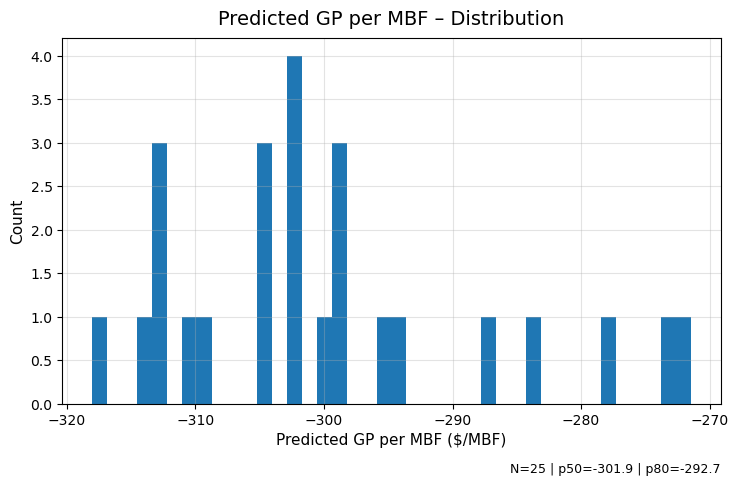

Saved: /Users/aniruddh/capstone_fall25/ai-mill-tool/models/plots/gp_line_dollars.png


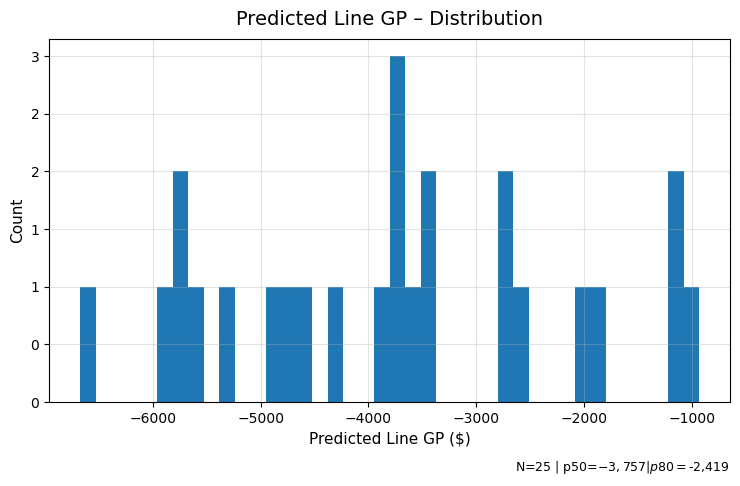

Saved: /Users/aniruddh/capstone_fall25/ai-mill-tool/models/plots/gp_vs_mbf.png


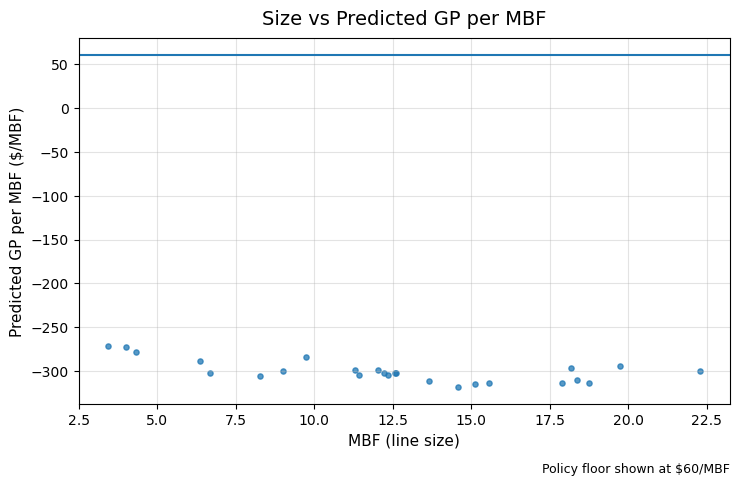

,Mill,CustomerName,Type of Shipment,MBF,pred_gp_per_mbf,pred_gp_$,exposure_$
24,MillB,CustY,F,22.304,-299.250122,-6674.474720,8012.714720
1,MillA,CustW,F,18.769,-312.818351,-5871.287633,6997.427633
20,MillC,CustX,F,19.756,-293.902192,-5806.331711,6991.691711
17,MillA,CustX,F,18.388,-309.690389,-5694.586866,6797.866866
22,MillC,CustY,LTL,17.896,-312.806184,-5597.979465,6671.739465
3,MillB,CustZ,F,18.189,-295.681266,-5378.146540,6469.486540
14,MillC,CustX,F,15.558,-312.806184,-4866.638607,5800.118607
9,MillC,CustY,V,15.114,-314.023603,-4746.152735,5652.992735
13,MillB,CustZ,F,14.572,-318.021187,-4634.204739,5508.524739
18,MillB,CustY,V,13.662,-310.896315,-4247.465455,5067.185455


In [119]:
plot_gp_hist(gp_df)
plot_gp_line_dollars(gp_df)
plot_gp_vs_size(gp_df, policy_floor=60.0)
table_gp_risky(gp_df, 60.0, 25)